<a href="https://colab.research.google.com/github/haten95/Actividades_IA/blob/main/Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 2. DEFINICIÓN DEL MODELO (Basado en papers de Transfer Learning Eficiente)
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Preprocesamiento: Marco de ceros (ZeroPadding) + Reescalado (UpSampling)
    # Pasamos de 32x32 -> 40x40 (padding) -> 80x80 (upscaling)
    layers.ZeroPadding2D(padding=(4, 4)),
    layers.UpSampling2D(size=(2, 2), interpolation='bilinear'),

    # Normalización específica para MobileNetV2
    layers.Lambda(applications.mobilenet_v2.preprocess_input),

    # Data Augmentation integrado para robustez
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    # Modelo Base: MobileNetV2 (rápido y eficiente)
    applications.MobileNetV2(input_shape=(80, 80, 3), include_top=False, weights='imagenet'),

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    # Capas densas con activación ELU
    layers.Dense(512, activation='elu', kernel_initializer='he_normal'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),

    layers.Dense(256, activation='elu', kernel_initializer='he_normal'),
    layers.Dense(10, activation='softmax')
])

# 3. CONGELACIÓN ESTRATÉGICA
# Congelamos solo el 70% del modelo base para permitir que las capas superiores
# se adapten al nuevo tamaño de 80x80 rápidamente.
model.layers[5].trainable = True # Corrected index to MobileNetV2 layer
for layer in model.layers[5].layers[:100]: # Corrected index to MobileNetV2 layer
    layer.trainable = False

# 4. COMPILACIÓN Y ENTRENAMIENTO
# Usamos un Learning Rate inicial de 1e-4 para estabilidad con ELU
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks para maximizar velocidad y eficiencia
lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

print("Iniciando entrenamiento con UpScaling (80x80), ZeroPadding y ELU...")
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=128, # Aumentamos batch_size para compensar el costo del UpScaling
    validation_data=(x_test, y_test),
    callbacks=[lr_reducer, early_stop]
)

# 5. GRÁFICAS DE RESULTADOS
plt.figure(figsize=(14, 5))

# Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación', color='#ff7f0e', linewidth=2)
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación', color='#ff7f0e', linewidth=2)
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_361/2507233202.py:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  applications.MobileNetV2(input_shape=(80, 80, 3), include_top=False, weights='imagenet'),


Iniciando entrenamiento con UpScaling (80x80), ZeroPadding y ELU...
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 263s 652ms/step - accuracy: 0.5548 - loss: 1.3211 - val_accuracy: 0.4895 - val_loss: 1.7431 - learning_rate: 1.0000e-04
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 250s 640ms/step - accuracy: 0.7127 - loss: 0.8298 - val_accuracy: 0.6890 - val_loss: 1.0213 - learning_rate: 1.0000e-04
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 250s 640ms/step - accuracy: 0.7604 - loss: 0.6878 - val_accuracy: 0.6996 - val_loss: 0.9867 - learning_rate: 1.0000e-04
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 252s 646ms/step - accuracy: 0.7842 - loss: 0.6089 - val_accuracy: 0.7689 - val_loss: 0.7578 - learning_rate: 1.0000e-04
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 252s 645ms/step - accuracy: 0.8069 - loss: 0.5511 - val_accuracy: 0.7931 - val_loss: 0.6446 - learning_rate: 1.0000e-04
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 250s 641ms/step - accuracy: 0.8215 - loss: 0.5094 - val_accuracy: 0.7967 - val_loss: 0.6261 

KeyboardInterrupt: 


--- EVALUACIÓN FINAL SOBRE DATOS DE TEST ---
Precisión final en Test: 85.49%
Pérdida final en Test: 0.4359
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


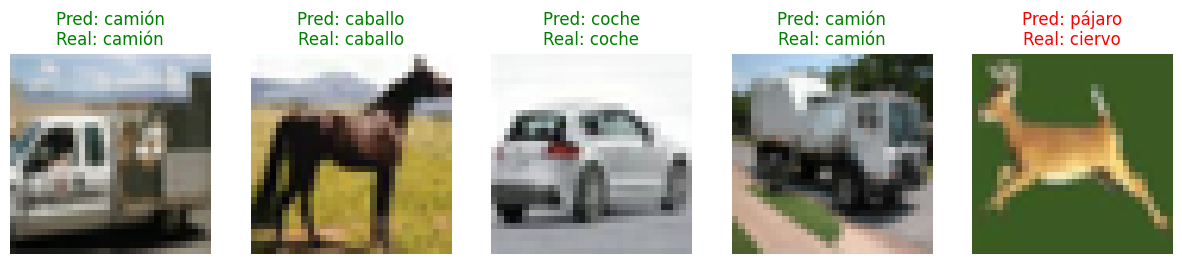

In [ ]:
# 1. EVALUACIÓN FORMAL
print("\n--- EVALUACIÓN FINAL SOBRE DATOS DE TEST ---")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Precisión final en Test: {test_acc*100:.2f}%")
print(f"Pérdida final en Test: {test_loss:.4f}")

# 2. PROBAR CON IMÁGENES INDIVIDUALES
import numpy as np

# Etiquetas de CIFAR-10 en orden
clases = ['avión', 'coche', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

# Tomar 5 imágenes aleatorias del set de test
indices = np.random.choice(range(len(x_test)), 5)
test_images = x_test[indices]
test_labels = np.argmax(y_test[indices], axis=1)

# Hacer la predicción
predictions = model.predict(test_images)
pred_labels = np.argmax(predictions, axis=1)

# Visualizar resultados
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images[i])
    color = 'green' if pred_labels[i] == test_labels[i] else 'red'
    plt.title(f"Pred: {clases[pred_labels[i]]}\nReal: {clases[test_labels[i]]}", color=color)
    plt.axis('off')
plt.show()